# Electric Vehicle Specification Analysis and Range Prediction

## AIS Solution – AI Internship Project

### Project Objective

The objective of this project is to analyze electric vehicle specifications and develop a machine learning model to predict the driving range of electric vehicles.

### Project Overview

This project covers:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Missing Value Handling
- Outlier Detection
- Data Visualization
- Correlation Analysis
- Feature Engineering
- Machine Learning
- Model Training
- Model Evaluation
- Range Prediction

### Machine Learning Target

The target variable for prediction is:

**range_km**

The model will use different electric vehicle specifications such as battery capacity, efficiency, charging power, top speed, torque, acceleration, seats, and other relevant features to predict the driving range of an electric vehicle.

### Dataset

The dataset contains electric vehicle specifications from different brands and models.

### Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
- GitHub

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the Electric Vehicle dataset

df = pd.read_csv("electric_vehicles_spec_2025.csv.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (478, 22)


In [4]:
# Display the first 5 rows

print("First 5 rows of the Electric Vehicle dataset:")
display(df.head())

First 5 rows of the Electric Vehicle dataset:


,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [5]:
# Display the last 5 rows

print("Last 5 rows of the dataset:")
display(df.tail())

Last 5 rows of the dataset:


,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
473,Zeekr,7X Premium RWD,210,71.0,Lithium-ion,NaN,440.0,148,365,6.0,...,2000.0,539,5,RWD,JD - Large,4787,1930,1650,SUV,https://ev-database.org/car/3081/Zeekr-7X-Prem...
474,Zeekr,X Core RWD (MY25),190,49.0,Lithium-ion,NaN,343.0,148,265,5.9,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475,Zeekr,X Long Range RWD (MY25),190,65.0,Lithium-ion,NaN,343.0,146,360,5.6,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3198/Zeekr-X-Long-...
476,Zeekr,X Privilege AWD (MY25),190,65.0,Lithium-ion,NaN,543.0,153,350,3.8,...,1600.0,362,5,AWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3199/Zeekr-X-Privi...
477,firefly,NaN,150,41.2,Lithium-ion,112.0,200.0,125,250,8.1,...,0.0,404,5,RWD,B - Compact,4003,1885,1557,Hatchback,https://ev-database.org/car/3178/firefly-firefly


In [6]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 478
Number of columns: 22


In [7]:
# Dataset information

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    str    
 1   model                      477 non-null    str    
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    str    
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    str    
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null 

In [8]:
# Display all column names

print("Column Names:")
for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Column Names:
1 - brand
2 - model
3 - top_speed_kmh
4 - battery_capacity_kWh
5 - battery_type
6 - number_of_cells
7 - torque_nm
8 - efficiency_wh_per_km
9 - range_km
10 - acceleration_0_100_s
11 - fast_charging_power_kw_dc
12 - fast_charge_port
13 - towing_capacity_kg
14 - cargo_volume_l
15 - seats
16 - drivetrain
17 - segment
18 - length_mm
19 - width_mm
20 - height_mm
21 - car_body_type
22 - source_url


In [9]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
brand                          0
model                          1
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64


In [10]:
# Missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
brand                         0.000000
model                         0.209205
top_speed_kmh                 0.000000
battery_capacity_kWh          0.000000
battery_type                  0.000000
number_of_cells              42.259414
torque_nm                     1.464435
efficiency_wh_per_km          0.000000
range_km                      0.000000
acceleration_0_100_s          0.000000
fast_charging_power_kw_dc     0.209205
fast_charge_port              0.209205
towing_capacity_kg            5.439331
cargo_volume_l                0.209205
seats                         0.000000
drivetrain                    0.000000
segment                       0.000000
length_mm                     0.000000
width_mm                      0.000000
height_mm                     0.000000
car_body_type                 0.000000
source_url                    0.000000
dtype: float64


In [11]:
# Statistical summary of numerical columns

print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,top_speed_kmh,battery_capacity_kWh,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
count,478.000000,478.000000,276.000000,471.000000,478.000000,478.000000,478.000000,477.000000,452.000000,478.000000,478.000000,478.000000,478.000000
mean,185.487448,74.043724,485.293478,498.012739,162.903766,393.179916,6.882636,125.008386,1052.261062,5.263598,4678.506276,1887.359833,1601.125523
std,34.252773,20.331058,1210.819733,241.461128,34.317532,103.287335,2.730696,58.205012,737.851774,1.003961,369.210573,73.656807,130.754851
min,125.000000,21.300000,72.000000,113.000000,109.000000,135.000000,2.200000,29.000000,0.000000,2.000000,3620.000000,1610.000000,1329.000000
25%,160.000000,60.000000,150.000000,305.000000,143.000000,320.000000,4.800000,80.000000,500.000000,5.000000,4440.000000,1849.000000,1514.000000
50%,180.000000,76.150000,216.000000,430.000000,155.000000,397.500000,6.600000,113.000000,1000.000000,5.000000,4720.000000,1890.000000,1596.000000
75%,201.000000,90.600000,324.000000,679.000000,177.750000,470.000000,8.200000,150.000000,1600.000000,5.000000,4961.000000,1939.000000,1665.000000
max,325.000000,118.000000,7920.000000,1350.000000,370.000000,685.000000,19.100000,281.000000,2500.000000,9.000000,5908.000000,2080.000000,1986.000000


In [12]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
# Display duplicate rows if any

if duplicate_count > 0:
    display(df[df.duplicated()])
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [14]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Duplicate rows removed successfully!")
print("Dataset Shape after removing duplicates:", df.shape)

Duplicate rows removed successfully!
Dataset Shape after removing duplicates: (478, 22)


In [16]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include=["str", "object"]).columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm']

Categorical Columns:
['brand', 'model', 'battery_type', 'fast_charge_port', 'cargo_volume_l', 'drivetrain', 'segment', 'car_body_type', 'source_url']


In [17]:
# Display data types of all columns

print("Data Types:")
display(df.dtypes)

Data Types:


brand                            str
model                            str
top_speed_kmh                  int64
battery_capacity_kWh         float64
battery_type                     str
number_of_cells              float64
torque_nm                    float64
efficiency_wh_per_km           int64
range_km                       int64
acceleration_0_100_s         float64
fast_charging_power_kw_dc    float64
fast_charge_port                 str
towing_capacity_kg           float64
cargo_volume_l                   str
seats                          int64
drivetrain                       str
segment                          str
length_mm                      int64
width_mm                       int64
height_mm                      int64
car_body_type                    str
source_url                       str
dtype: object

In [18]:
# Check unique values in categorical columns

for column in categorical_columns:
    print(f"\n{column}")
    print("Number of unique values:", df[column].nunique())
    print("Unique values:")
    print(df[column].unique()[:20])


brand
Number of unique values: 59
Unique values:
<StringArray>
[  'Abarth',   'Aiways',     'Alfa',   'Alpine',     'Audi',      'BMW',
      'BYD',    'CUPRA', 'Cadillac',  'Citroen',       'DS',    'Dacia',
 'Dongfeng',   'Elaris',     'Fiat',     'Ford',      'GWM',  'Genesis',
    'Honda',   'Hongqi']
Length: 20, dtype: str

model
Number of unique values: 477
Unique values:
<StringArray>
[                    '500e Convertible',
                       '500e Hatchback',
                  '600e Scorpionissima',
                         '600e Turismo',
                                   'U5',
                                   'U6',
        'Romeo Junior Elettrica 54 kWh',
 'Romeo Junior Elettrica 54 kWh Veloce',
                 'A290 Electric 180 hp',
                 'A290 Electric 220 hp',
                      'A6 Avant e-tron',
          'A6 Avant e-tron performance',
              'A6 Avant e-tron quattro',
                  'A6 Sportback e-tron',
      'A6 Sportback e-tron per

In [19]:
# Display only columns that contain missing values

missing_data = df.isnull().sum()

missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Columns with Missing Values:")
display(missing_data)

Columns with Missing Values:


number_of_cells              202
towing_capacity_kg            26
torque_nm                      7
model                          1
fast_charging_power_kw_dc      1
fast_charge_port               1
cargo_volume_l                 1
dtype: int64

In [20]:
# Missing value percentage

missing_percentage = (missing_data / len(df)) * 100

print("Missing Value Percentage:")
display(missing_percentage)

Missing Value Percentage:


number_of_cells              42.259414
towing_capacity_kg            5.439331
torque_nm                     1.464435
model                         0.209205
fast_charging_power_kw_dc     0.209205
fast_charge_port              0.209205
cargo_volume_l                0.209205
dtype: float64

In [21]:
# Handle missing values in numerical columns

for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Missing numerical values handled successfully!")

Missing numerical values handled successfully!


In [22]:
# Handle missing values in categorical columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing categorical values handled successfully!")

Missing categorical values handled successfully!


In [23]:
# Verify remaining missing values

print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


In [24]:
# Verify cleaned dataset

print("Dataset Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (478, 22)

Remaining Missing Values:
0

Duplicate Rows:
0


In [25]:
# Display cleaned dataset

display(df.head())

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,216.0,310.0,156,315,7.5,...,1000.0,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution, patterns, relationships, and unusual values in the Electric Vehicle dataset.

The analysis will include:

- Numerical feature distributions
- Categorical feature analysis
- Correlation analysis
- Outlier detection
- Relationship between EV specifications and driving range

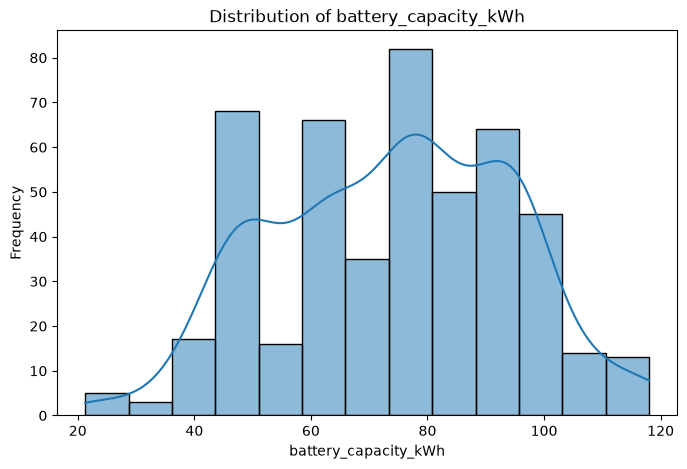

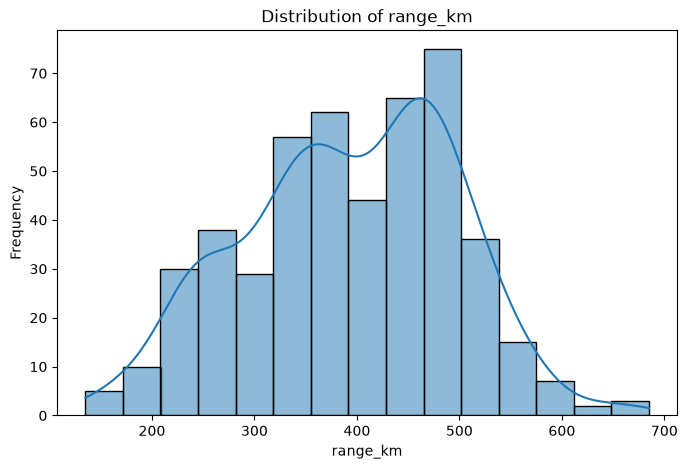

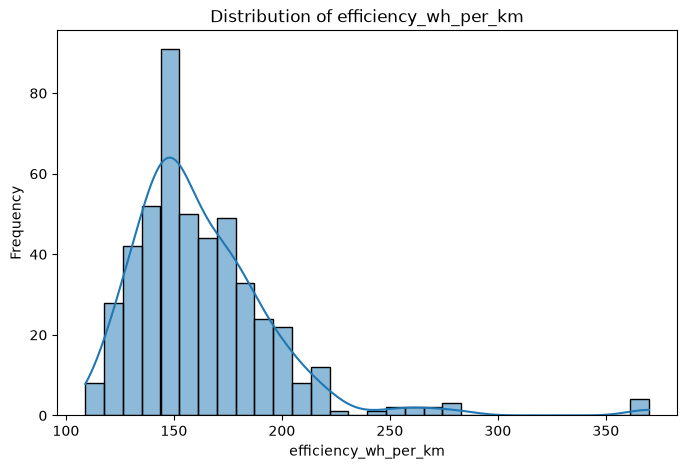

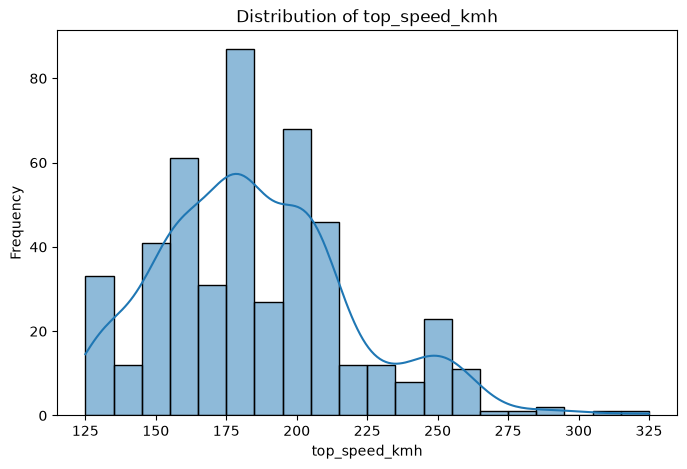

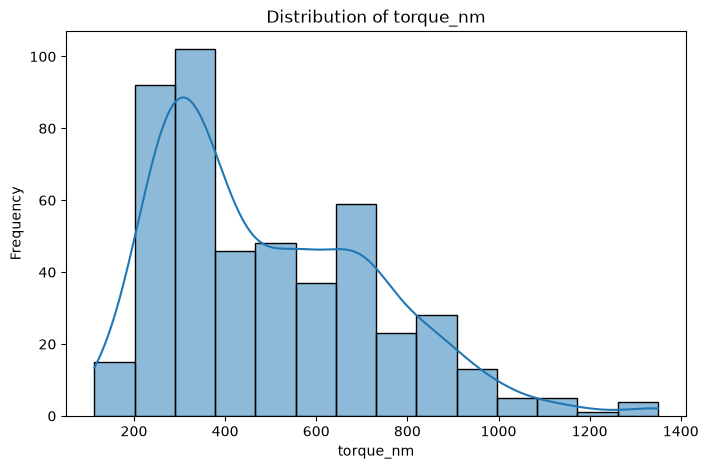

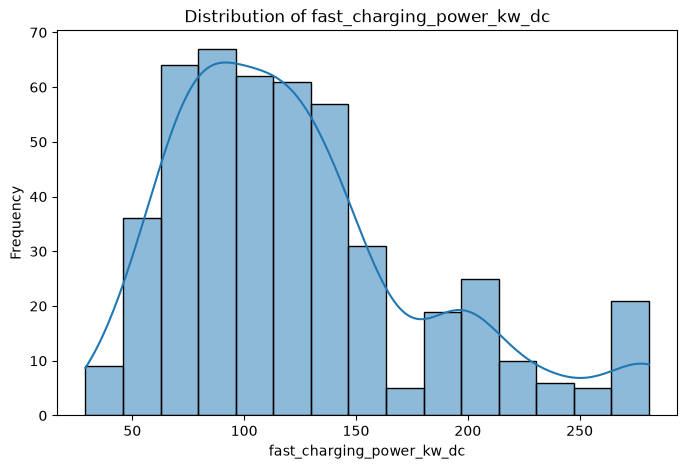

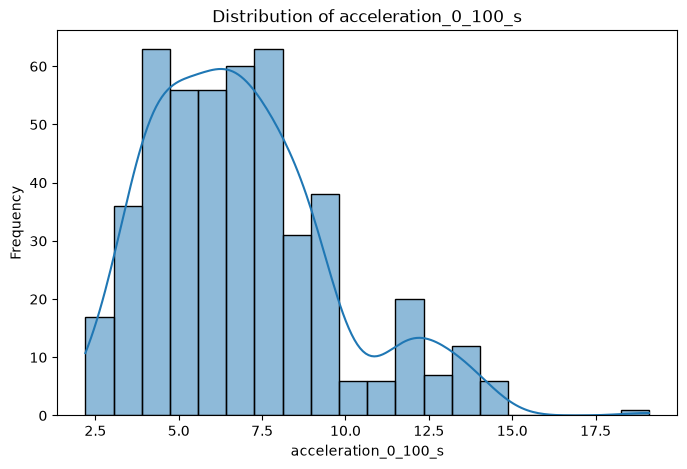

In [26]:
# Distribution of important numerical EV features

important_features = [
    "battery_capacity_kWh",
    "range_km",
    "efficiency_wh_per_km",
    "top_speed_kmh",
    "torque_nm",
    "fast_charging_power_kw_dc",
    "acceleration_0_100_s"
]

for column in important_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [27]:
# Count electric vehicles by brand

brand_counts = df["brand"].value_counts()

print("Number of EVs by Brand:")
display(brand_counts)

Number of EVs by Brand:


brand
Mercedes-Benz    42
Audi             28
Porsche          26
Volkswagen       23
Ford             22
BMW              20
Peugeot          19
Volvo            18
BYD              17
Smart            17
Kia              16
Hyundai          14
Opel             14
Citroen          12
MG               12
NIO              12
Skoda            12
Renault          11
Tesla            11
Polestar          9
XPENG             9
Zeekr             9
Fiat              8
Mini              8
Toyota            7
GWM               6
Lotus             6
Nissan            6
CUPRA             5
DS                5
Genesis           5
Abarth            4
Hongqi            3
Lexus             3
Lucid             3
Maserati          3
Aiways            2
Alfa              2
Alpine            2
Dacia             2
Dongfeng          2
Jeep              2
Leapmotor         2
Mazda             2
Skywell           2
VinFast           2
Cadillac          1
Elaris            1
Honda             1
Jaguar        

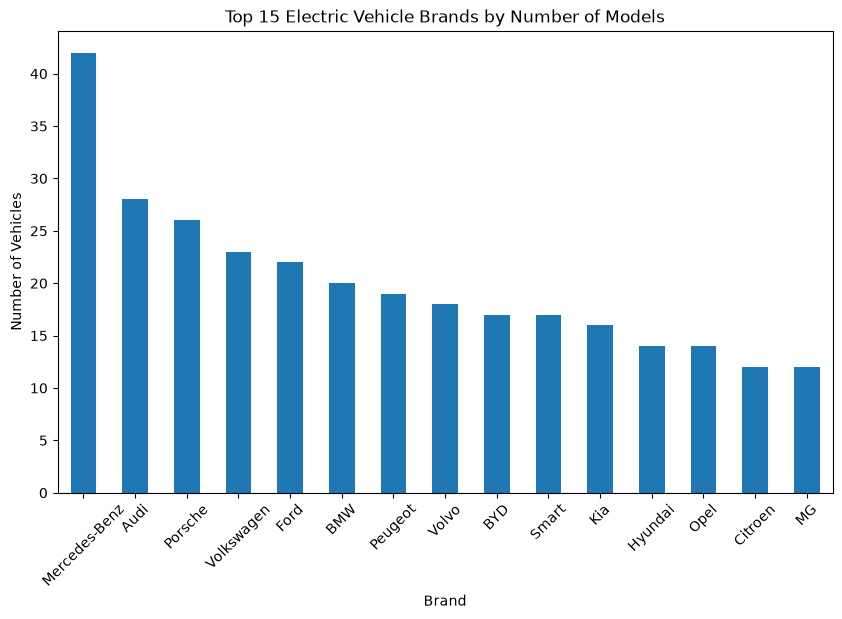

In [28]:
# Top 15 EV brands

plt.figure(figsize=(10, 6))

brand_counts.head(15).plot(kind="bar")

plt.title("Top 15 Electric Vehicle Brands by Number of Models")
plt.xlabel("Brand")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)

plt.show()

In [29]:
# Count EVs by battery type

battery_type_counts = df["battery_type"].value_counts()

print("Number of EVs by Battery Type:")
display(battery_type_counts)

Number of EVs by Battery Type:


battery_type
Lithium-ion    478
Name: count, dtype: int64

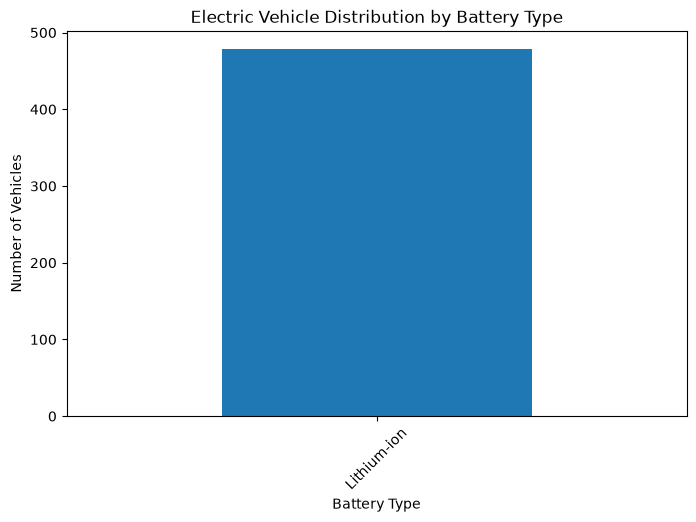

In [30]:
# Battery type distribution

plt.figure(figsize=(8, 5))

battery_type_counts.plot(kind="bar")

plt.title("Electric Vehicle Distribution by Battery Type")
plt.xlabel("Battery Type")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)

plt.show()

In [31]:
# Count EVs by drivetrain type

drivetrain_counts = df["drivetrain"].value_counts()

print("Number of EVs by Drivetrain:")
display(drivetrain_counts)

Number of EVs by Drivetrain:


drivetrain
AWD    191
FWD    156
RWD    131
Name: count, dtype: int64

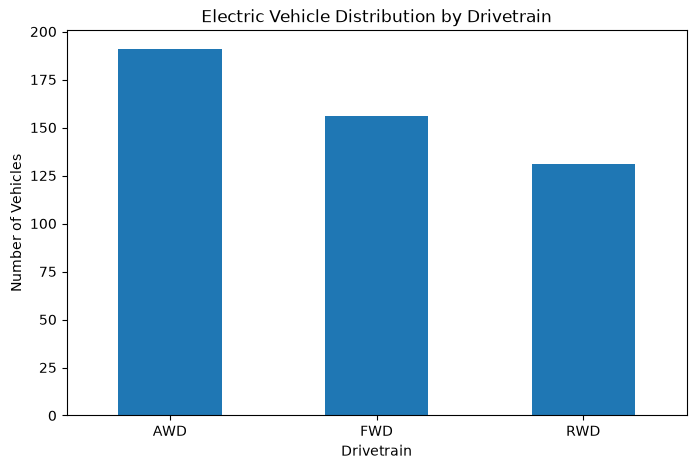

In [32]:
# Drivetrain distribution

plt.figure(figsize=(8, 5))

drivetrain_counts.plot(kind="bar")

plt.title("Electric Vehicle Distribution by Drivetrain")
plt.xlabel("Drivetrain")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=0)

plt.show()

In [33]:
# Count EVs by car body type

body_type_counts = df["car_body_type"].value_counts()

print("Number of EVs by Car Body Type:")
display(body_type_counts)

Number of EVs by Car Body Type:


car_body_type
SUV                    244
Sedan                   63
Hatchback               57
Small Passenger Van     47
Liftback Sedan          33
Station/Estate          27
Cabriolet                5
Coupe                    2
Name: count, dtype: int64

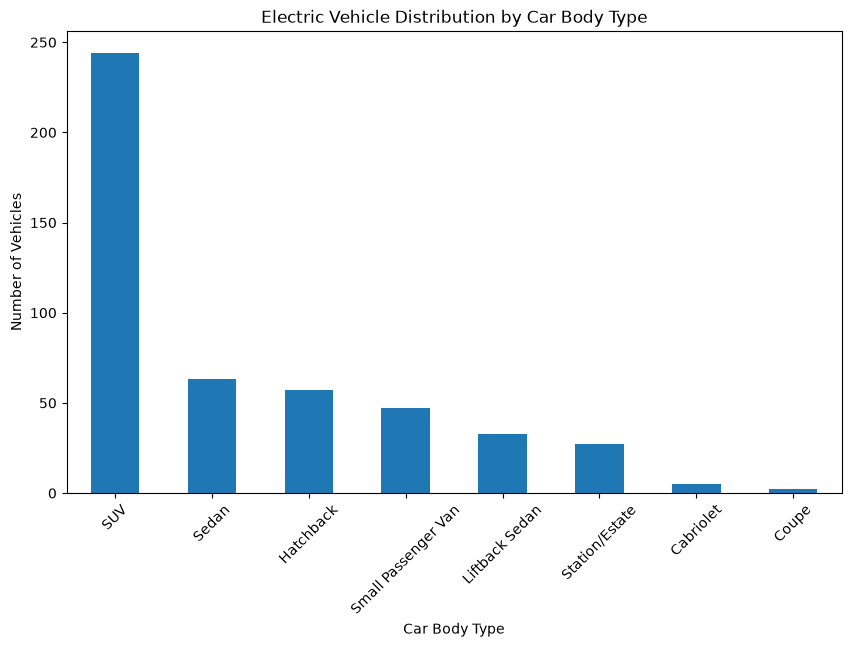

In [34]:
# Car body type distribution

plt.figure(figsize=(10, 6))

body_type_counts.plot(kind="bar")

plt.title("Electric Vehicle Distribution by Car Body Type")
plt.xlabel("Car Body Type")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)

plt.show()

In [35]:
# Count EVs by vehicle segment

segment_counts = df["segment"].value_counts()

print("Number of EVs by Segment:")
display(segment_counts)

Number of EVs by Segment:


segment
JC - Medium          91
JD - Large           58
F - Luxury           51
N - Passenger Van    47
JB - Compact         44
C - Medium           34
E - Executive        30
JF - Luxury          30
B - Compact          29
JE - Executive       28
D - Large            28
A - Mini              3
JA - Mini             2
G - Sports            2
I - Luxury            1
Name: count, dtype: int64

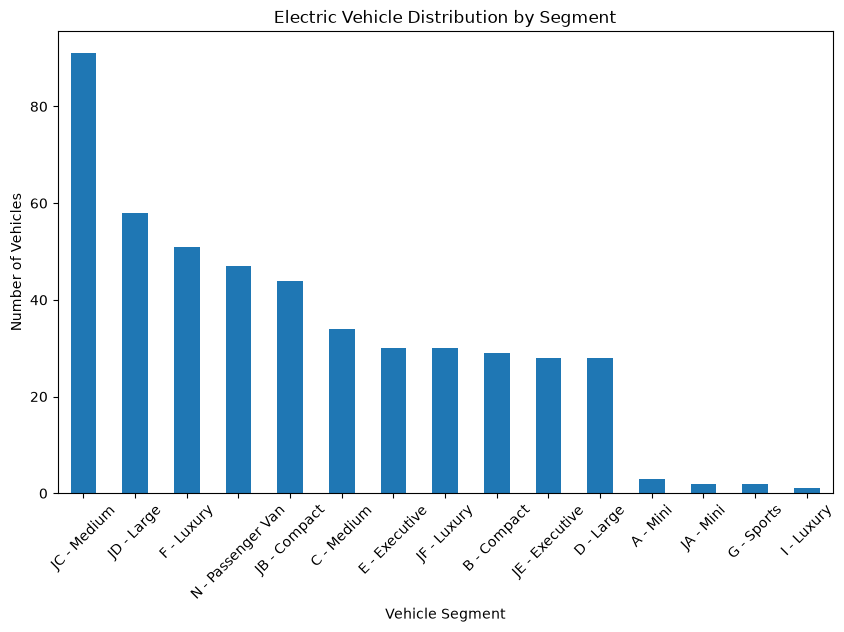

In [36]:
# Vehicle segment distribution

plt.figure(figsize=(10, 6))

segment_counts.plot(kind="bar")

plt.title("Electric Vehicle Distribution by Segment")
plt.xlabel("Vehicle Segment")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)

plt.show()

In [37]:
# Basic statistics of EV driving range

print("Driving Range Statistics:")
print("Minimum Range:", df["range_km"].min(), "km")
print("Maximum Range:", df["range_km"].max(), "km")
print("Average Range:", df["range_km"].mean(), "km")
print("Median Range:", df["range_km"].median(), "km")

Driving Range Statistics:
Minimum Range: 135 km
Maximum Range: 685 km
Average Range: 393.1799163179916 km
Median Range: 397.5 km


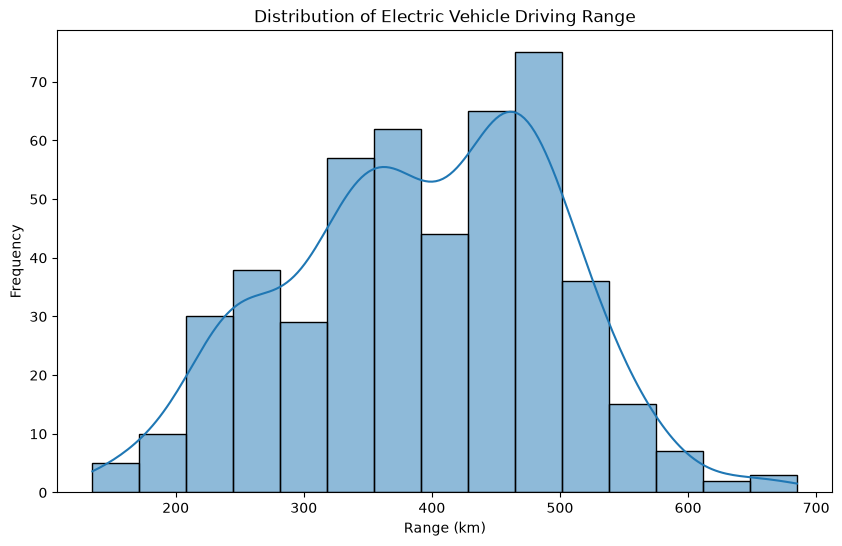

In [38]:
# Distribution of EV driving range

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="range_km", kde=True)

plt.title("Distribution of Electric Vehicle Driving Range")
plt.xlabel("Range (km)")
plt.ylabel("Frequency")

plt.show()

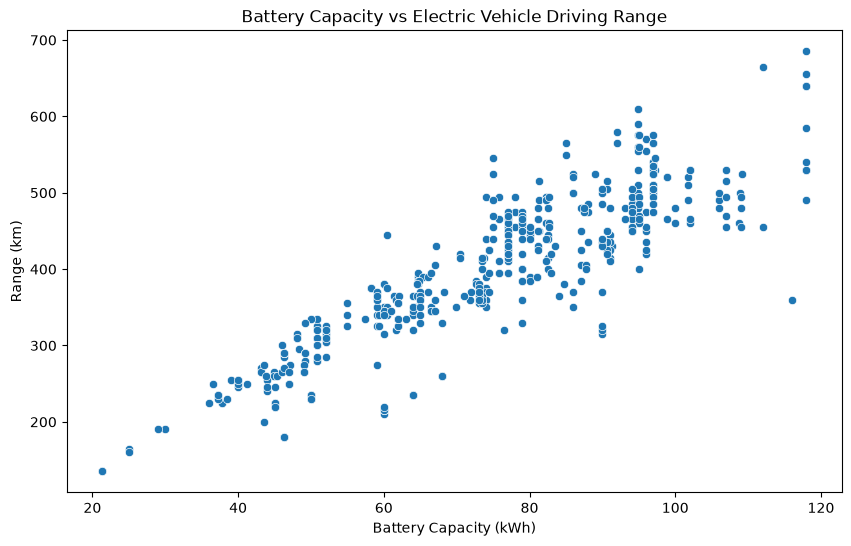

In [39]:
# Battery capacity vs driving range

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="battery_capacity_kWh",
    y="range_km"
)

plt.title("Battery Capacity vs Electric Vehicle Driving Range")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")

plt.show()

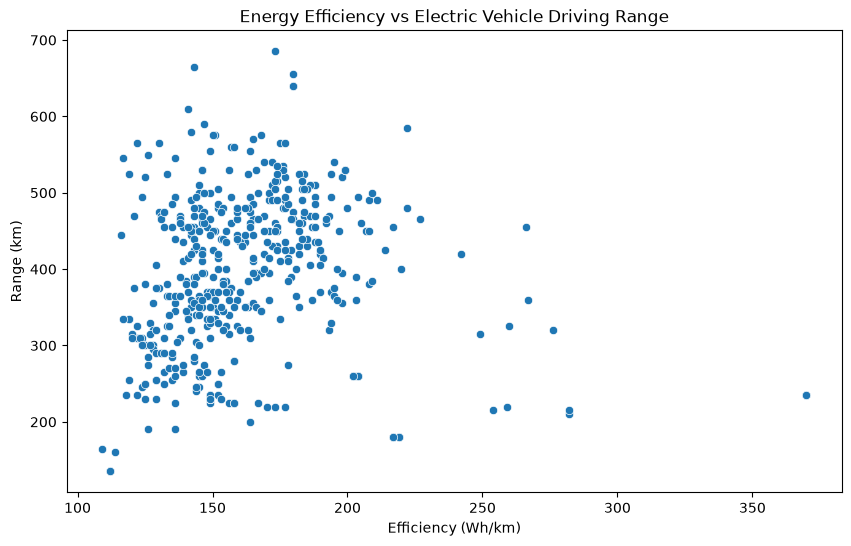

In [40]:
# Efficiency vs driving range

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="efficiency_wh_per_km",
    y="range_km"
)

plt.title("Energy Efficiency vs Electric Vehicle Driving Range")
plt.xlabel("Efficiency (Wh/km)")
plt.ylabel("Range (km)")

plt.show()

In [41]:
# Correlation matrix for numerical features

correlation_matrix = df[numerical_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,top_speed_kmh,battery_capacity_kWh,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
top_speed_kmh,1.000000,0.708486,0.278957,0.777897,0.171242,0.732130,-0.823443,0.770347,0.219832,-0.315572,0.443686,0.535850,-0.462712
battery_capacity_kWh,0.708486,1.000000,0.151204,0.747546,0.383607,0.880433,-0.643716,0.726611,0.440899,0.013413,0.689293,0.731496,-0.055999
number_of_cells,0.278957,0.151204,1.000000,0.051118,-0.060177,0.237162,-0.202035,0.086152,0.032547,0.038313,0.130980,0.157179,-0.112088
torque_nm,0.777897,0.747546,0.051118,1.000000,0.370654,0.636849,-0.773713,0.653336,0.329972,-0.162833,0.502635,0.561468,-0.191299
efficiency_wh_per_km,0.171242,0.383607,-0.060177,0.370654,1.000000,0.022943,-0.066512,0.182264,0.245808,0.522634,0.644838,0.573535,0.512614
range_km,0.732130,0.880433,0.237162,0.636849,0.022943,1.000000,-0.712486,0.720123,0.329475,-0.248784,0.496867,0.521392,-0.413798
acceleration_0_100_s,-0.823443,-0.643716,-0.202035,-0.773713,-0.066512,-0.712486,1.000000,-0.627013,-0.277712,0.441376,-0.254990,-0.395869,0.494811
fast_charging_power_kw_dc,0.770347,0.726611,0.086152,0.653336,0.182264,0.720123,-0.627013,1.000000,0.232887,-0.127987,0.472829,0.574152,-0.289767
towing_capacity_kg,0.219832,0.440899,0.032547,0.329972,0.245808,0.329475,-0.277712,0.232887,1.000000,0.148628,0.388154,0.443608,0.293504
seats,-0.315572,0.013413,0.038313,-0.162833,0.522634,-0.248784,0.441376,-0.127987,0.148628,1.000000,0.458281,0.305574,0.697256


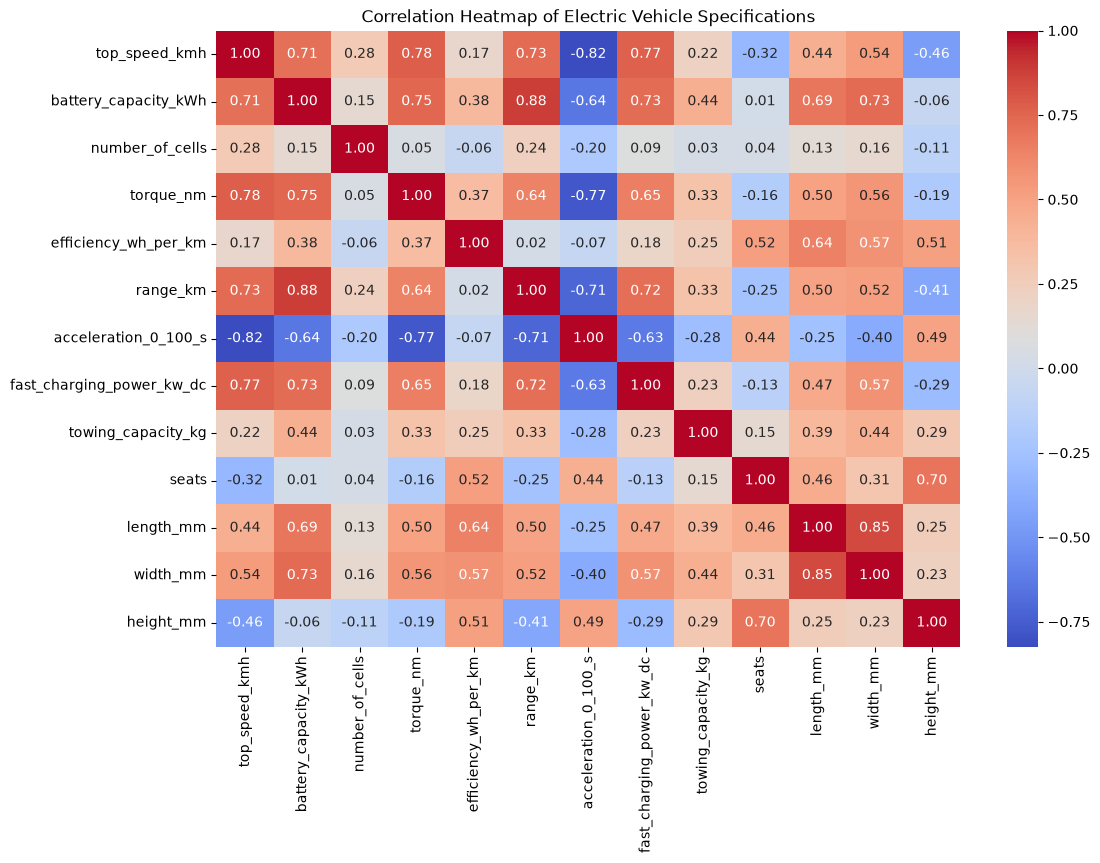

In [42]:
# Correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Electric Vehicle Specifications")

plt.show()

In [43]:
# Correlation of features with driving range

range_correlation = correlation_matrix["range_km"].sort_values(ascending=False)

print("Correlation of Numerical Features with Range:")
display(range_correlation)

Correlation of Numerical Features with Range:


range_km                     1.000000
battery_capacity_kWh         0.880433
top_speed_kmh                0.732130
fast_charging_power_kw_dc    0.720123
torque_nm                    0.636849
width_mm                     0.521392
length_mm                    0.496867
towing_capacity_kg           0.329475
number_of_cells              0.237162
efficiency_wh_per_km         0.022943
seats                       -0.248784
height_mm                   -0.413798
acceleration_0_100_s        -0.712486
Name: range_km, dtype: float64

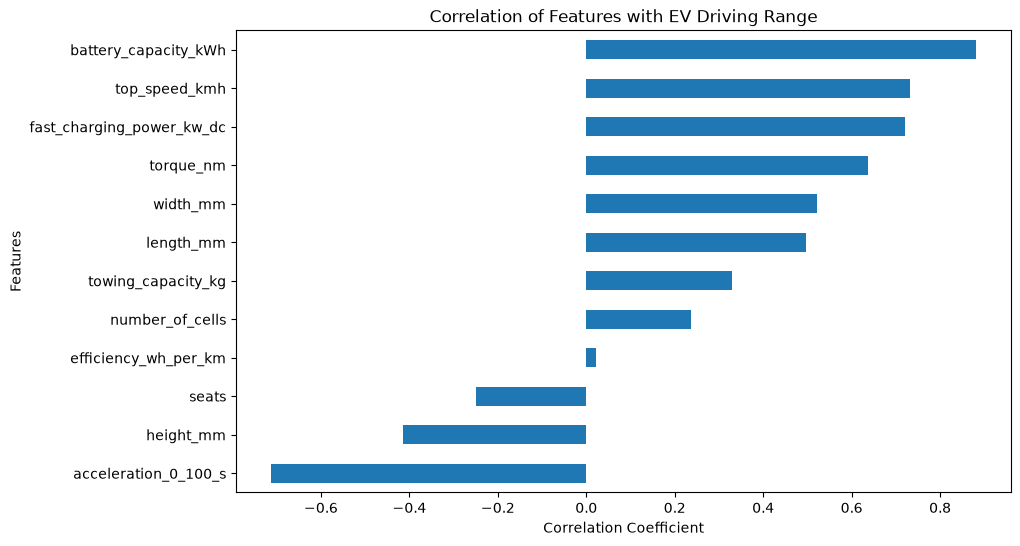

In [44]:
# Plot correlations with range

plt.figure(figsize=(10, 6))

range_correlation.drop("range_km").sort_values().plot(kind="barh")

plt.title("Correlation of Features with EV Driving Range")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

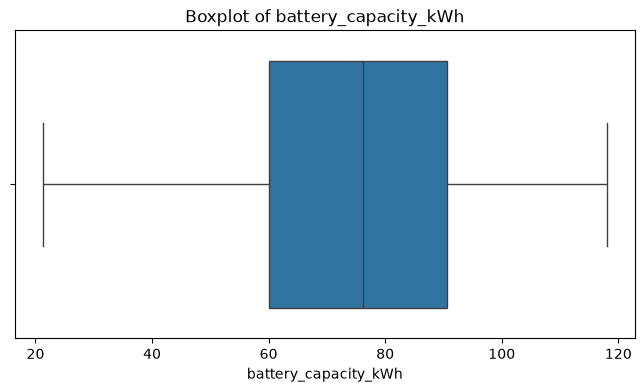

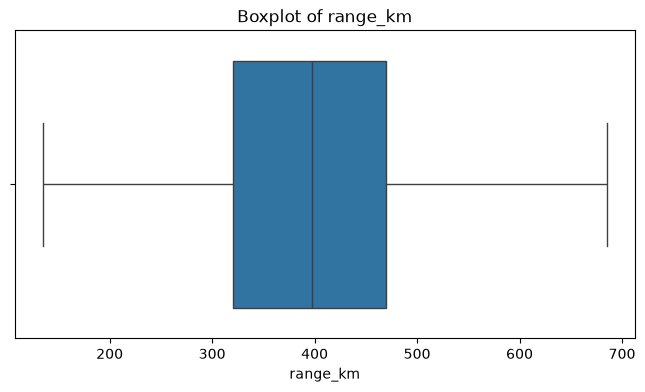

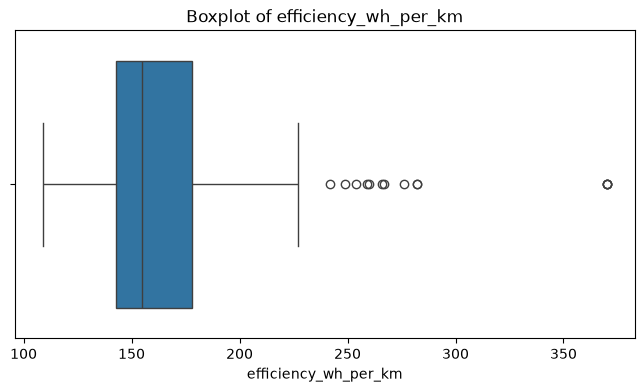

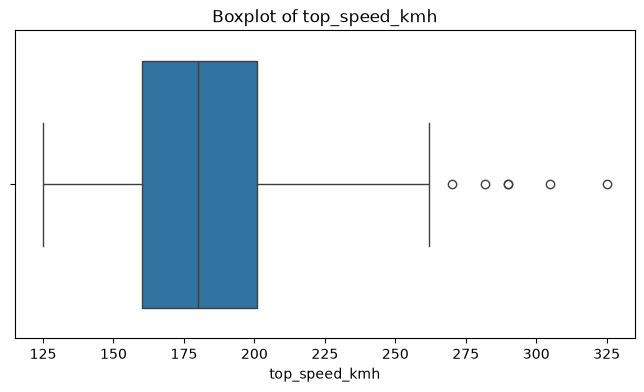

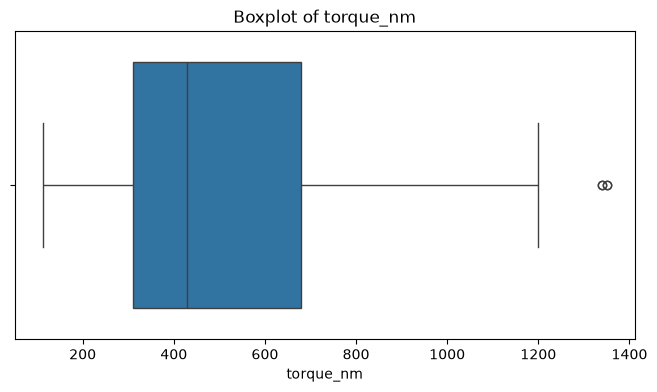

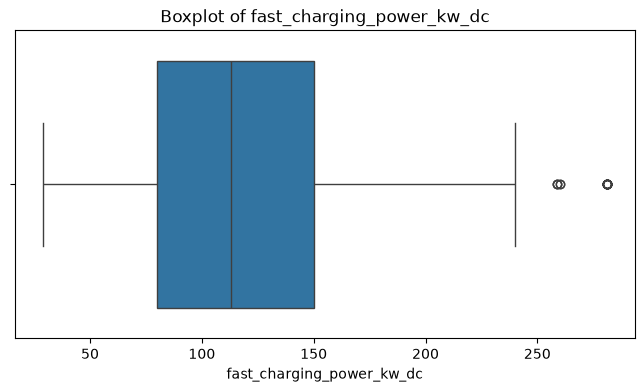

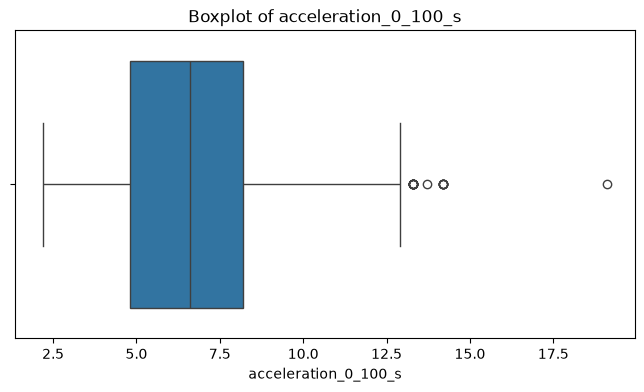

In [45]:
# Boxplots for important numerical features

outlier_features = [
    "battery_capacity_kWh",
    "range_km",
    "efficiency_wh_per_km",
    "top_speed_kmh",
    "torque_nm",
    "fast_charging_power_kw_dc",
    "acceleration_0_100_s"
]

for column in outlier_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    
    plt.show()

In [46]:
# Outlier detection using IQR / Tukey method

outlier_results = []

for column in outlier_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]
    
    outlier_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Number of Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Limit,Upper Limit,Number of Outliers
0,battery_capacity_kWh,60.0,90.60,30.60,14.100,136.500,0
1,range_km,320.0,470.00,150.00,95.000,695.000,0
2,efficiency_wh_per_km,143.0,177.75,34.75,90.875,229.875,14
3,top_speed_kmh,160.0,201.00,41.00,98.500,262.500,6
4,torque_nm,310.0,679.00,369.00,-243.500,1232.500,4
5,fast_charging_power_kw_dc,80.0,150.00,70.00,-25.000,255.000,26
6,acceleration_0_100_s,4.8,8.20,3.40,-0.300,13.300,19


In [47]:
# Display features with outliers

print("Outlier Summary:")
display(
    outlier_summary[
        ["Feature", "Number of Outliers"]
    ].sort_values(
        by="Number of Outliers",
        ascending=False
    )
)

Outlier Summary:


,Feature,Number of Outliers
5,fast_charging_power_kw_dc,26
6,acceleration_0_100_s,19
2,efficiency_wh_per_km,14
3,top_speed_kmh,6
4,torque_nm,4
1,range_km,0
0,battery_capacity_kWh,0


In [48]:
# Total number of outlier observations across selected features

total_outliers = outlier_summary["Number of Outliers"].sum()

print("Total Outlier Observations:", total_outliers)

Total Outlier Observations: 69


In [49]:
# Z-Score outlier detection

from scipy.stats import zscore

zscore_data = df[outlier_features].apply(zscore)

zscore_outlier_count = (abs(zscore_data) > 3).sum()

print("Number of Z-Score Outliers (|Z| > 3):")
display(zscore_outlier_count)

Number of Z-Score Outliers (|Z| > 3):


battery_capacity_kWh         0
range_km                     0
efficiency_wh_per_km         9
top_speed_kmh                4
torque_nm                    4
fast_charging_power_kw_dc    0
acceleration_0_100_s         1
dtype: int64

In [50]:
# Compare IQR and Z-Score outliers

comparison = pd.DataFrame({
    "Feature": outlier_features,
    "IQR Outliers": outlier_summary["Number of Outliers"].values,
    "Z-Score Outliers": zscore_outlier_count.values
})

display(comparison)

,Feature,IQR Outliers,Z-Score Outliers
0,battery_capacity_kWh,0,0
1,range_km,0,0
2,efficiency_wh_per_km,14,9
3,top_speed_kmh,6,4
4,torque_nm,4,4
5,fast_charging_power_kw_dc,26,0
6,acceleration_0_100_s,19,1


In [51]:
# Feature Engineering

df["battery_per_seat"] = df["battery_capacity_kWh"] / df["seats"]

df["charging_power_per_battery"] = (
    df["fast_charging_power_kw_dc"] / df["battery_capacity_kWh"]
)

print("New features created successfully!")

display(
    df[
        [
            "battery_capacity_kWh",
            "seats",
            "battery_per_seat",
            "fast_charging_power_kw_dc",
            "charging_power_per_battery"
        ]
    ].head()
)

New features created successfully!


,battery_capacity_kWh,seats,battery_per_seat,fast_charging_power_kw_dc,charging_power_per_battery
0,37.8,4,9.45,67.0,1.772487
1,37.8,4,9.45,67.0,1.772487
2,50.8,5,10.16,79.0,1.555118
3,50.8,5,10.16,79.0,1.555118
4,60.0,5,12.00,78.0,1.300000


In [52]:
# Define features and target

features = [
    "top_speed_kmh",
    "battery_capacity_kWh",
    "number_of_cells",
    "torque_nm",
    "efficiency_wh_per_km",
    "acceleration_0_100_s",
    "fast_charging_power_kw_dc",
    "towing_capacity_kg",
    "seats",
    "length_mm",
    "width_mm",
    "height_mm",
    "battery_per_seat",
    "charging_power_per_battery"
]

X = df[features]
y = df["range_km"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:")
print(list(X.columns))

print("\nTarget variable:")
print("range_km")

Features (X) shape: (478, 14)
Target (y) shape: (478,)

Feature columns:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm', 'battery_per_seat', 'charging_power_per_battery']

Target variable:
range_km


In [53]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (382, 14)
Testing data shape: (96, 14)
Training target shape: (382,)
Testing target shape: (96,)


In [54]:
# Train Linear Regression model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [55]:
# Predict EV range using Linear Regression

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression predictions:")
print(y_pred_linear[:10])

Linear Regression predictions:
[500.4502491  463.89174332 196.10179721 415.90064463 419.99120111
 291.87051572 402.09306788 368.93154619 292.03514145 300.40344798]


In [56]:
# Evaluate Linear Regression model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE  :", mae_linear)
print("MSE  :", mse_linear)
print("RMSE :", rmse_linear)
print("R²   :", r2_linear)

Linear Regression Performance
--------------------------------
MAE  : 19.53955609041456
MSE  : 580.8094759638251
RMSE : 24.099989127877738
R²   : 0.9451122046883753


In [57]:
# Actual vs Predicted Range

comparison_df = pd.DataFrame({
    "Actual Range (km)": y_test.values,
    "Predicted Range (km)": y_pred_linear
})

display(comparison_df.head(10))

,Actual Range (km),Predicted Range (km)
0,480,500.450249
1,495,463.891743
2,235,196.101797
3,415,415.900645
4,445,419.991201
5,320,291.870516
6,400,402.093068
7,365,368.931546
8,290,292.035141
9,305,300.403448


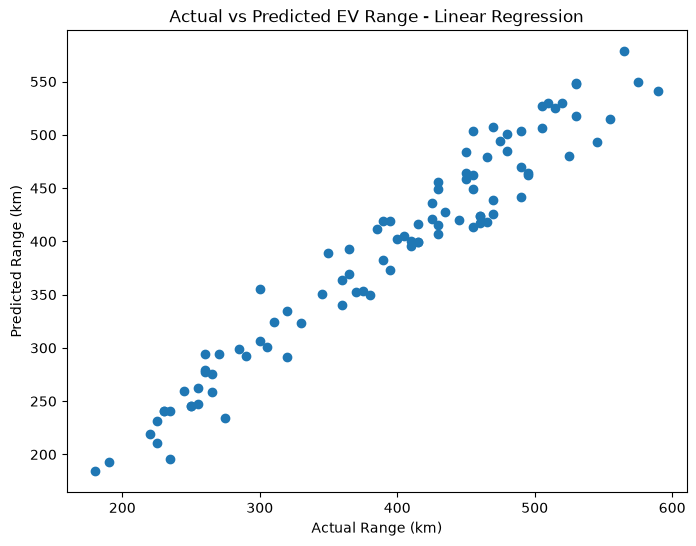

In [58]:
# Actual vs Predicted plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear
)

plt.xlabel("Actual Range (km)")
plt.ylabel("Predicted Range (km)")
plt.title("Actual vs Predicted EV Range - Linear Regression")

plt.show()

In [59]:
# Train Random Forest Regression model

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [60]:
# Predict EV range using Random Forest

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf[:10])

Random Forest predictions:
[484.475      476.95       233.425      427.975      447.85
 307.075      406.09166667 347.45       302.725      305.9       ]


In [61]:
# Evaluate Random Forest Regression model

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance")
print("--------------------------------------")
print("MAE  :", mae_rf)
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest Regression Performance
--------------------------------------
MAE  : 13.000943390376987
MSE  : 339.88786748675204
RMSE : 18.43604804416478
R²   : 0.967879835864318


In [62]:
# Compare Linear Regression and Random Forest

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "MSE": [
        mse_linear,
        mse_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

display(model_results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,19.539556,580.809476,24.099989,0.945112
1,Random Forest Regression,13.000943,339.887867,18.436048,0.967880


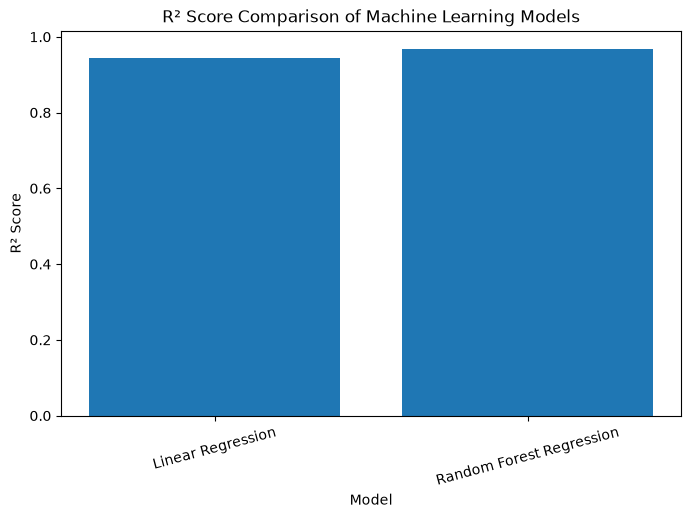

In [63]:
# Compare R² scores

plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["R2 Score"]
)

plt.title("R² Score Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

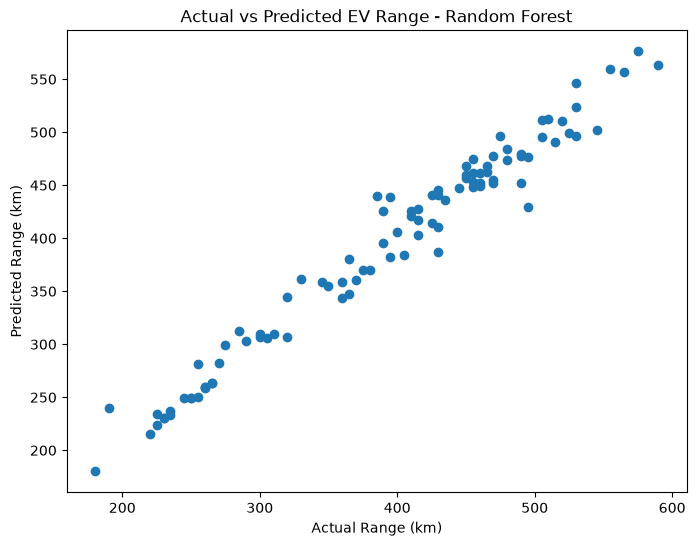

In [64]:
# Actual vs Predicted Range - Random Forest

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Range (km)")
plt.ylabel("Predicted Range (km)")
plt.title("Actual vs Predicted EV Range - Random Forest")

plt.show()

In [65]:
# Feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
12,battery_per_seat,0.589681
1,battery_capacity_kWh,0.284266
11,height_mm,0.052356
4,efficiency_wh_per_km,0.021900
6,fast_charging_power_kw_dc,0.013614
9,length_mm,0.007675
10,width_mm,0.006140
3,torque_nm,0.005825
5,acceleration_0_100_s,0.005577
13,charging_power_per_battery,0.005067


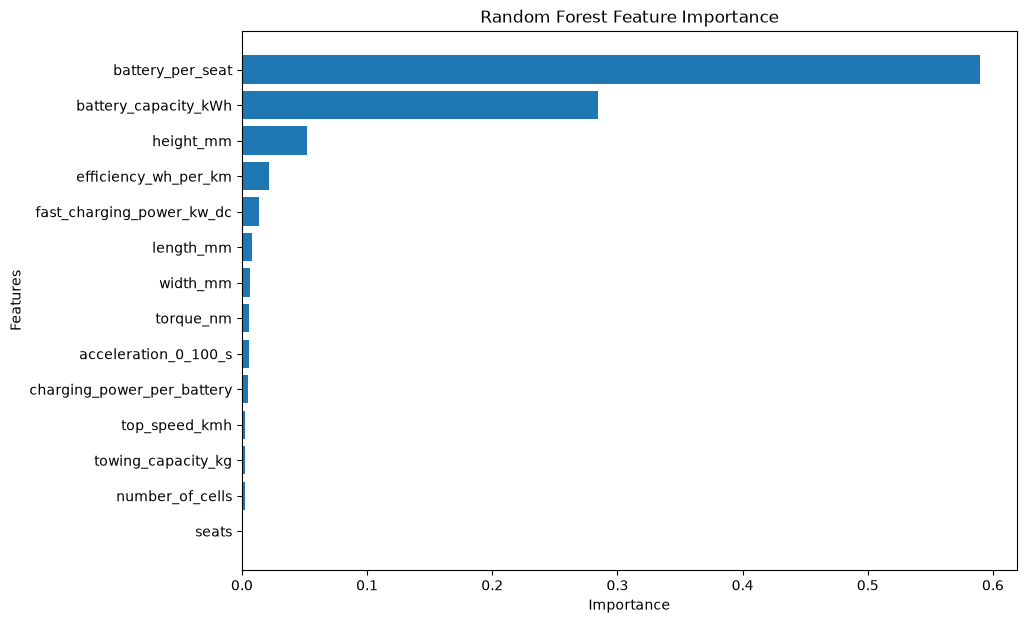

In [66]:
# Plot feature importance

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [67]:
# Create specifications for a new electric vehicle

new_ev = pd.DataFrame({
    "top_speed_kmh": [180],
    "battery_capacity_kWh": [60],
    "number_of_cells": [400],
    "torque_nm": [300],
    "efficiency_wh_per_km": [160],
    "acceleration_0_100_s": [7.5],
    "fast_charging_power_kw_dc": [100],
    "towing_capacity_kg": [750],
    "seats": [5],
    "length_mm": [4500],
    "width_mm": [1800],
    "height_mm": [1600],
    "battery_per_seat": [60 / 5],
    "charging_power_per_battery": [100 / 60]
})

predicted_range = random_forest_model.predict(new_ev)

print("Predicted Driving Range:", round(predicted_range[0], 2), "km")

Predicted Driving Range: 339.38 km


In [68]:
# Final model performance summary

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE (km)": [
        mae_linear,
        mae_rf
    ],
    "MSE": [
        mse_linear,
        mse_rf
    ],
    "RMSE (km)": [
        rmse_linear,
        rmse_rf
    ],
    "R² Score": [
        r2_linear,
        r2_rf
    ]
})

final_results = final_results.round(4)

print("Final Machine Learning Model Performance:")
display(final_results)

Final Machine Learning Model Performance:


,Model,MAE (km),MSE,RMSE (km),R² Score
0,Linear Regression,19.5396,580.8095,24.100,0.9451
1,Random Forest Regression,13.0009,339.8879,18.436,0.9679


## Conclusion

In this project, Electric Vehicle specifications were analyzed using Python and Machine Learning techniques.

The project included:

- Data loading and understanding
- Data cleaning and duplicate removal
- Missing value handling
- Exploratory Data Analysis
- Numerical and categorical feature analysis
- Correlation analysis
- Outlier detection using IQR and Z-Score methods
- Feature engineering
- Train-test splitting
- Linear Regression
- Random Forest Regression
- Model evaluation using MAE, MSE, RMSE, and R² Score
- Actual vs predicted range visualization
- Random Forest feature importance analysis
- Prediction of driving range for a new electric vehicle

The target variable used for prediction was **range_km**.

Two regression models were developed and evaluated. Their performance was compared using multiple regression metrics. The Random Forest model was also used to analyze the importance of different EV specifications in predicting driving range.

This project demonstrates an end-to-end **Data Analysis and Machine Learning workflow** for Electric Vehicle specification analysis and driving range prediction.

## Project Summary

### Project Title
**Electric Vehicle Specification Analysis and Range Prediction using Machine Learning**

### Dataset
- **Rows:** 478
- **Columns:** 22
- **Target Variable:** `range_km`

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### Data Analysis
- Data cleaning
- Missing value handling
- Duplicate detection
- Exploratory Data Analysis
- Correlation analysis
- Visualization
- Outlier detection using IQR and Z-Score

### Machine Learning
- Train-Test Split (80:20)
- Linear Regression
- Random Forest Regression
- MAE
- MSE
- RMSE
- R² Score
- Feature Importance
- New EV Range Prediction

### Outcome

The project demonstrates how electric vehicle specifications can be analyzed and used to build machine learning models for predicting **electric vehicle driving range**.